<a href="https://colab.research.google.com/github/grgpratibha/test/blob/master/scrape_Maydayepisodes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

scrape information from the https://en.wikipedia.org/wiki/List_of_Mayday_episodes

## installing necessary modules

In [ ]:
! pip install requests beautifulsoup4
! pip install nltk wordcloud

## Mount the drive and set the working directory

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks')

## Start scraping data from wikipedia page using requests and BeautiulSoup

In [ ]:
# import the necessary modules
import requests
from bs4 import BeautifulSoup
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
import re
import matplotlib.pyplot as plt

from collections import Counter
import string
import pandas as pd

In [ ]:
# get the stopwords from NLTK
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Browser's Developer Tool -> inspect element -> style class of desired table??

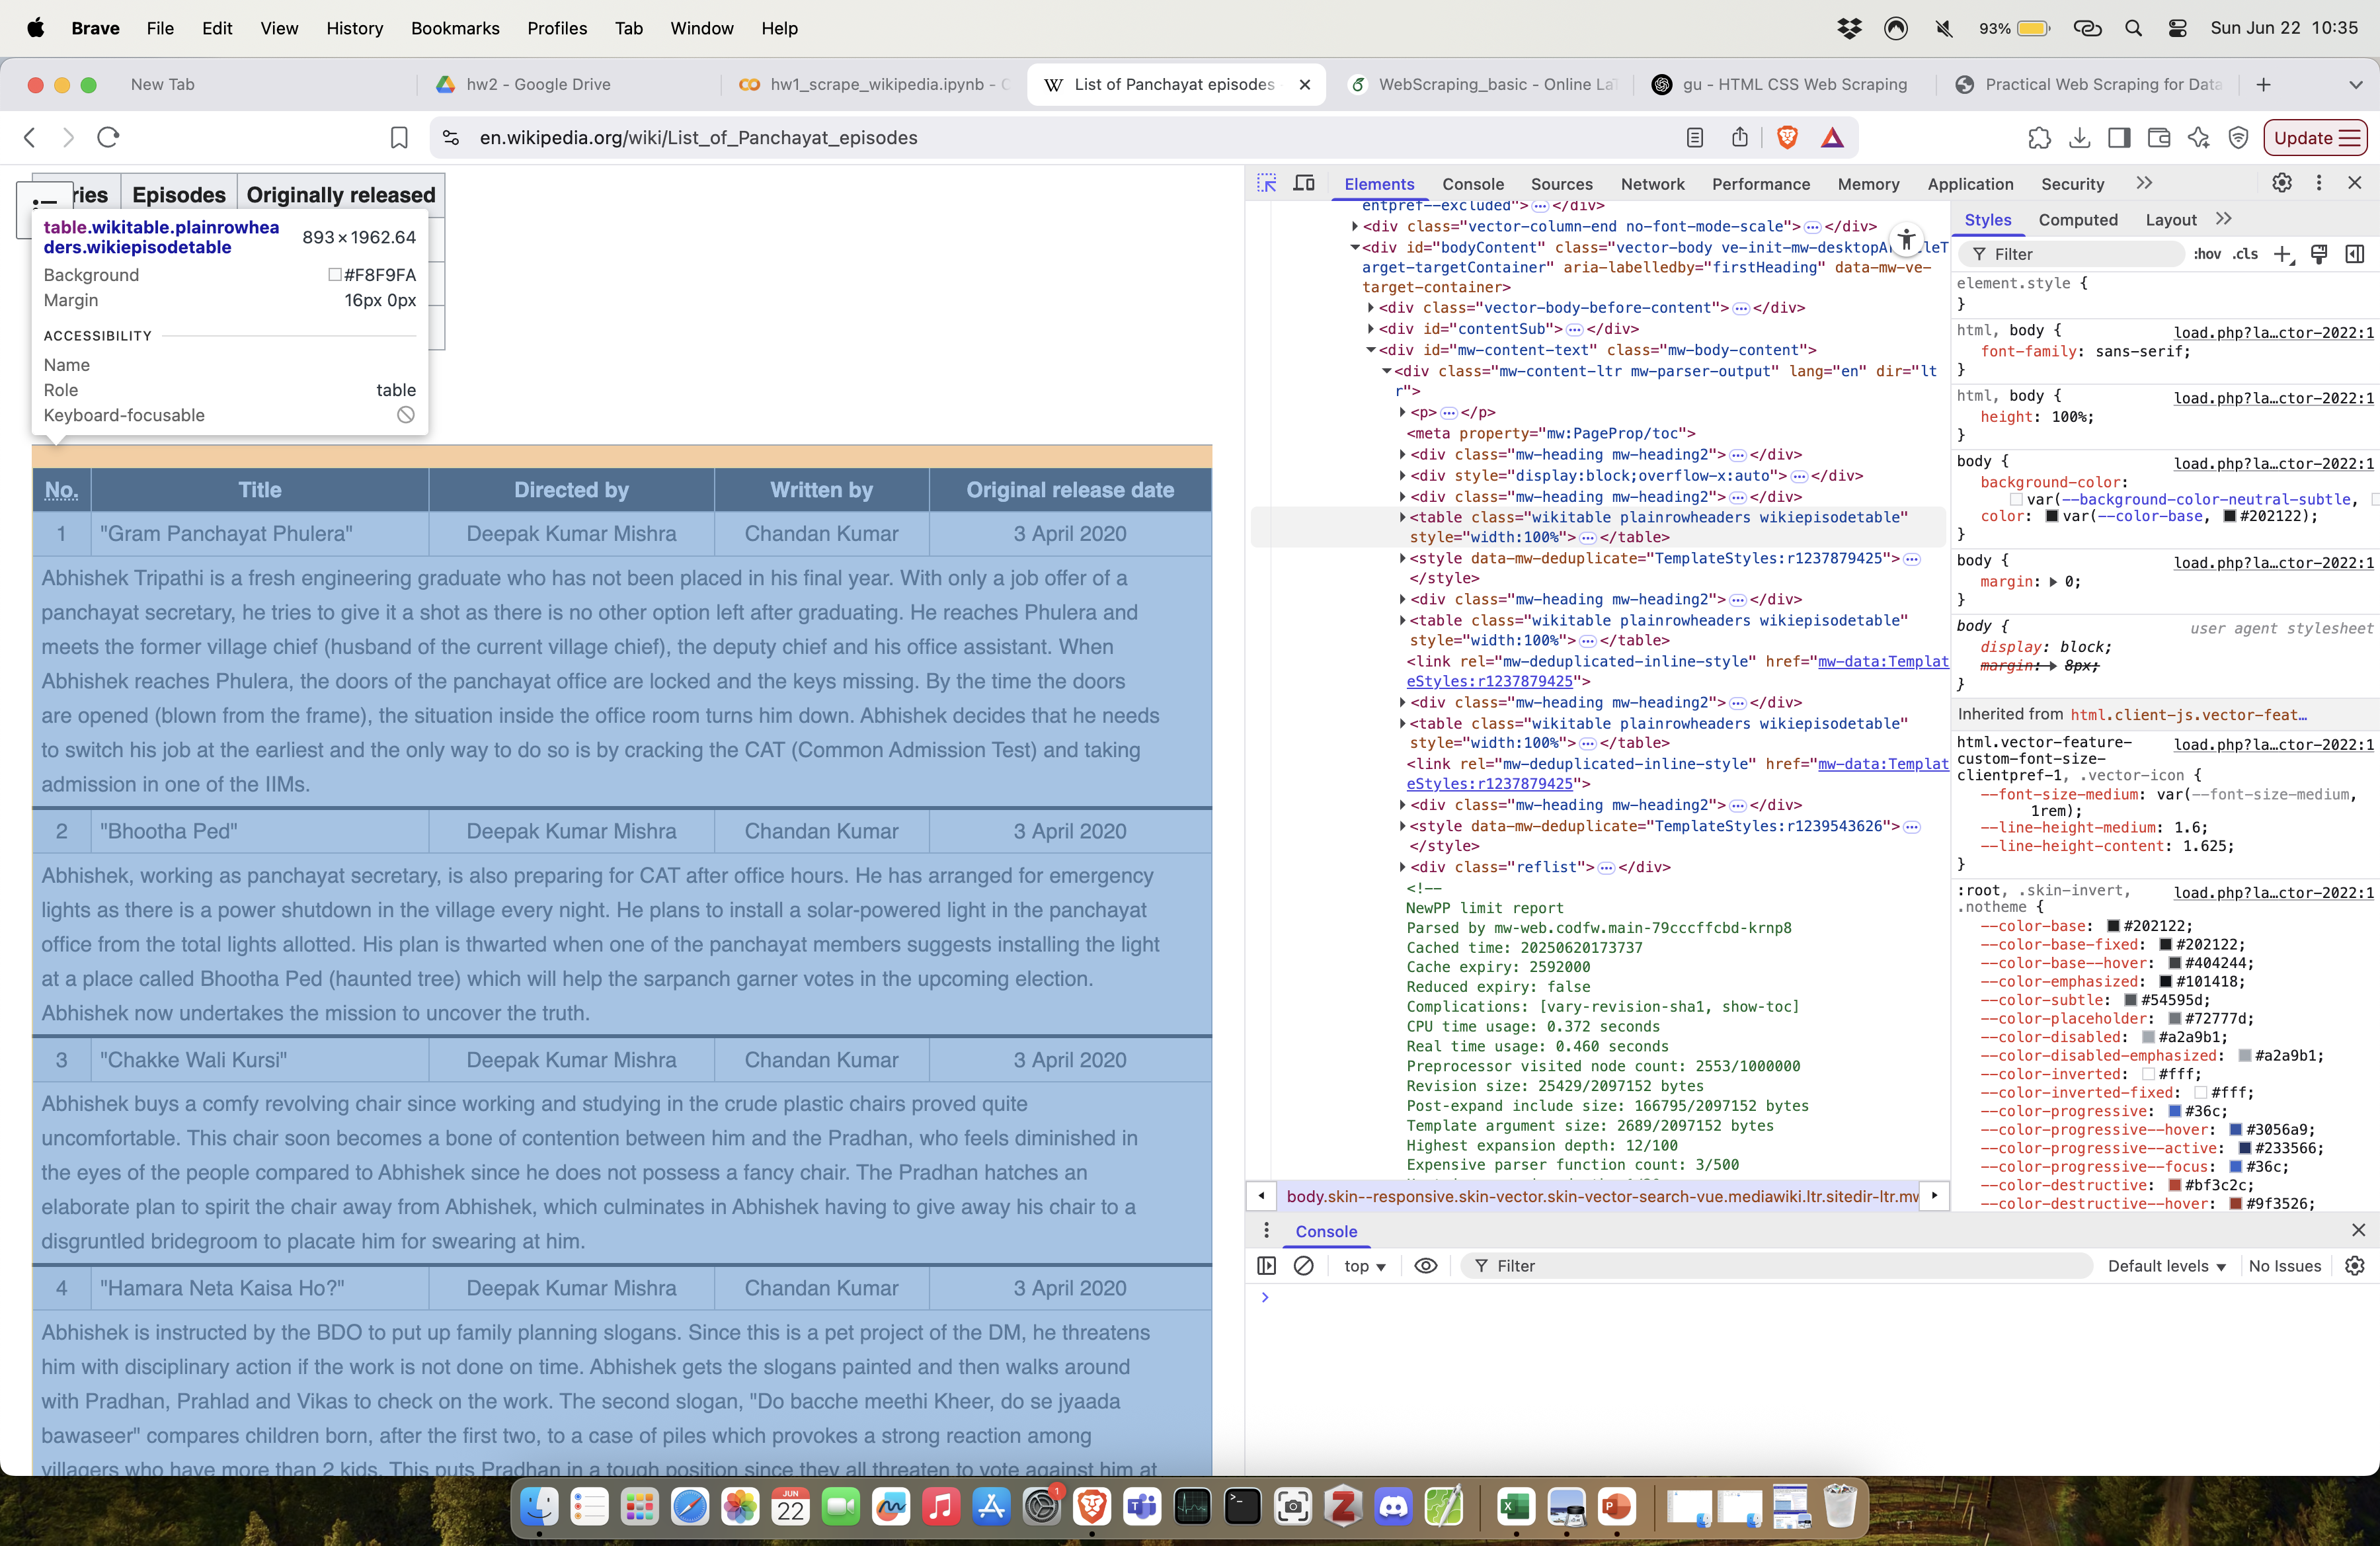

can we use any of the following?

```
soup.find_all('table', class_='wikiepisodetable')  

soup.find_all('table', class_='wikitable plainrowheaders wikiepisodetable')

soup.find_all('table', attrs={'class': ['wikitable', 'wikiepisodetable']})

```

In [ ]:
# Define our functions here
def save_episode_data( html_soup):

    episodes = []
    #ep_tables = html_soup.find_all('table', class_='wikiepisodetable')
    ep_tables = html_soup.find_all('table', class_='wikitable plainrowheaders wikiepisodetable')

    for table in ep_tables:
        headers = []
        rows = table.find_all('tr')
    # Start by fetching the header cells from the first row to determine
    # the field names
        for header in table.find('tr').find_all('th'):
            headers.append(header.text)
    # print(headers)
    # Then go through all the rows except the first one
        for row in table.find_all('tr')[1:]:
            values = []
            # And get the column cells, the first one being inside a th-tag
            for col in row.find_all(['th','td']):
                values.append(col.text)
            if values:
                episode_dict = {}
                for i in range(len(values)):
                  episode_dict[headers[i]]= values[i]
                episodes.append(episode_dict)

    return episodes


# display word cloud from text
def print_wordcloud(str_text):

    wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(str_text)
    # now display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

    return

# function to extract specific field values
def get_field_episodes(field_name, episodes):
    str_text = ''
    list_values = [(dd.get(field_name, 'N/A')) for dd in episodes]
    for tt in list_values:
        if tt != 'N/A':
            str_text += tt + ' '
    return str_text

#load saved file
def read_html_file(file_path):
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            html_content = file.read()
        return html_content
    except FileNotFoundError:
        print(f"File '{file_path}' not found.")
        return None


# read the text from the HTML content
def extract_text_from_html(html_content):

    soup = BeautifulSoup(html_content, 'html.parser')
    soup_text = soup.get_text()

    return soup_text


# Now, clean the text by removing stopwords and special characters
def clean_text(text):

    # remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()  # change to lowercase

    # tokenize the text and remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]

    # finally, join the filtered words back into a single string
    filtered_text = " ".join(filtered_words)

    return filtered_text






def get_top_n_words(text, n=10):
    # Convert text to lowercase and remove punctuation
    text = text.lower().translate(str.maketrans('', '', string.punctuation))

    # Tokenize the text into words
    words = text.split()

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]

    # Count word frequencies
    word_freq = Counter(filtered_words)

    # Return the top N most common words
    return word_freq.most_common(n)


Lets do the webscraping and processing the data

In [ ]:
#1. scrape the URL and save the html contents
url = "https://en.wikipedia.org/wiki/List_of_Mayday_episodes"
response = requests.get(url)
if response.status_code != 200:
    exit()


html_contents = response.text
# save the html page contents
with open("mayday_episodes.html", "w", encoding="utf-8") as file:
    file.write(html_contents)
print("HTML Page's content saved locally to 'mayday_episodes.html'.")


html_soup = BeautifulSoup(html_contents, 'html.parser')

# Storing the episode list
episodes = save_episode_data( html_soup)

# Show the results

for i in range(len(episodes)):
    print(episodes[i])
    break # if we want to print all data then comment this line

HTML Page's content saved locally to 'mayday_episodes.html'.
{'No.overall': '1', 'No. inseries': '1', 'Title': '"Unlocking Disaster"', 'Incident': 'United Airlines Flight 811', 'Original release date': '10\xa0September\xa02003\xa0(2003-09-10)'}


## Using pickle to dump the data in 'episodes'

In [ ]:
import pickle
# Filepath to save the pickle file
pickle_file = "mayday_episodes.pkl"

# Save the `episodes` list to a pickle file
with open(pickle_file, "wb") as file:
    pickle.dump(episodes, file)

pickle_file

'mayday_episodes.pkl'

## Loding the 'episodes' back

In [ ]:
# Step 3: Loading Variables
loaded_episodes = None

# Open the file in binary mode
with open(pickle_file, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_episodes = pickle.load(file)

print("The variable 'data' has been loaded successfully.")

print("Loaded Data:", loaded_episodes)

The variable 'data' has been loaded successfully.
Loaded Data: [{'No.overall': '1', 'No. inseries': '1', 'Title': '"Unlocking Disaster"', 'Incident': 'United Airlines Flight 811', 'Original release date': '10\xa0September\xa02003\xa0(2003-09-10)'}, {'No.overall': "\n\nOn 24 February 1989, part of the right-side fuselage of United Airlines Flight 811 rips off, ejecting nine people from the aircraft and causing an explosive decompression. The flight later lands safely at Honolulu without any more loss of life. It was later determined that an electrical short circuit caused the cargo door to open.\nNote: This accident is covered again in the Season 24 episode 'Terror Over The Pacific'.\n\n\nType of aircraft: Boeing 747-100"}, {'No.overall': '2', 'No. inseries': '2', 'Title': '"Racing the Storm"', 'Incident': 'American Airlines Flight 1420', 'Original release date': '3\xa0September\xa02003\xa0(2003-09-03)'}, {'No.overall': '\n\nOn 1 June 1999, American Airlines Flight 1420 tries to land at

In [ ]:
# lets display some loaded data
loaded_episodes[:1]

[{'No.overall': '1',
  'No. inseries': '1',
  'Title': '"Unlocking Disaster"',
  'Incident': 'United Airlines Flight 811',
  'Original release date': '10\xa0September\xa02003\xa0(2003-09-10)'}]

In [ ]:
# lets display some loaded data
loaded_episodes[:2]

[{'No.overall': '1',
  'No. inseries': '1',
  'Title': '"Unlocking Disaster"',
  'Incident': 'United Airlines Flight 811',
  'Original release date': '10\xa0September\xa02003\xa0(2003-09-10)'},
 {'No.overall': "\n\nOn 24 February 1989, part of the right-side fuselage of United Airlines Flight 811 rips off, ejecting nine people from the aircraft and causing an explosive decompression. The flight later lands safely at Honolulu without any more loss of life. It was later determined that an electrical short circuit caused the cargo door to open.\nNote: This accident is covered again in the Season 24 episode 'Terror Over The Pacific'.\n\n\nType of aircraft: Boeing 747-100"}]

In [ ]:
# lets display some loaded data
loaded_episodes[:4]

[{'No.overall': '1',
  'No. inseries': '1',
  'Title': '"Unlocking Disaster"',
  'Incident': 'United Airlines Flight 811',
  'Original release date': '10\xa0September\xa02003\xa0(2003-09-10)'},
 {'No.overall': "\n\nOn 24 February 1989, part of the right-side fuselage of United Airlines Flight 811 rips off, ejecting nine people from the aircraft and causing an explosive decompression. The flight later lands safely at Honolulu without any more loss of life. It was later determined that an electrical short circuit caused the cargo door to open.\nNote: This accident is covered again in the Season 24 episode 'Terror Over The Pacific'.\n\n\nType of aircraft: Boeing 747-100"},
 {'No.overall': '2',
  'No. inseries': '2',
  'Title': '"Racing the Storm"',
  'Incident': 'American Airlines Flight 1420',
  'Original release date': '3\xa0September\xa02003\xa0(2003-09-03)'},
 {'No.overall': '\n\nOn 1 June 1999, American Airlines Flight 1420 tries to land at the Little Rock National Airport during a s

## Lets display the wordclouds

In [ ]:
str_titles = get_field_episodes('Title', loaded_episodes)
str_desc = get_field_episodes('No.', loaded_episodes) # check if this filed can get the descriptions!!!


Wordclouds of Titles only


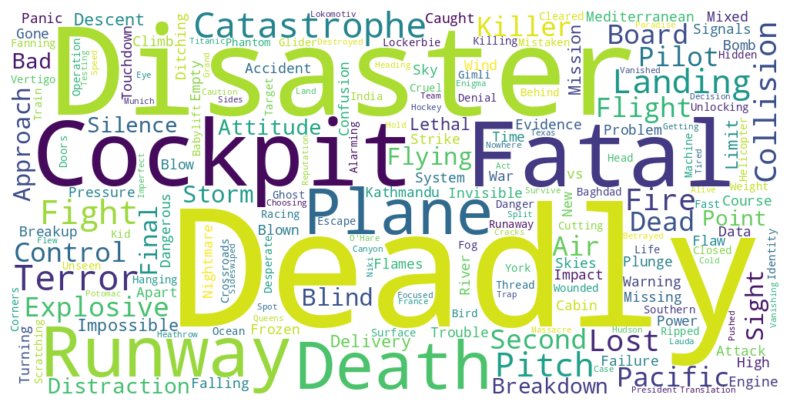

In [ ]:


print ("Wordclouds of Titles only")
print_wordcloud(str_titles)



In [ ]:
print ("Wordclouds of Description ")
print_wordcloud(str_desc)


Wordclouds of Description 


ValueError: We need at least 1 word to plot a word cloud, got 0.

Wordclouds of Titles and Description


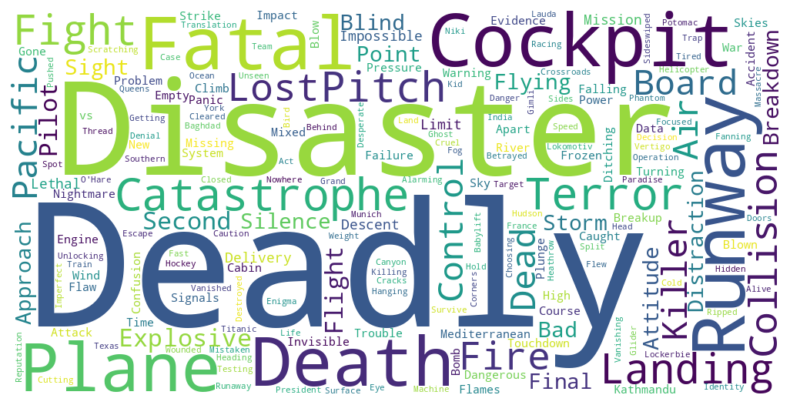

In [ ]:

print ("Wordclouds of Titles and Description")
print_wordcloud(str_titles +' '+ str_desc)

In [ ]:

# Convert  list of dictionaries (loaded_episodes) into a pandas DataFrame.
# Parameters: episodloaded_episodeses (list): List of dictionaries, where each dictionary is an episode with fields.

df_episode= pd.DataFrame(loaded_episodes)
df_episode.head()

,No.overall,No. inseries,Title,Incident,Original release date
0,1,1,"""Unlocking Disaster""",United Airlines Flight 811,10 September 2003 (2003-09-10)
1,"\n\nOn 24 February 1989, part of the right-sid...",NaN,NaN,NaN,NaN
2,2,2,"""Racing the Storm""",American Airlines Flight 1420,3 September 2003 (2003-09-03)
3,"\n\nOn 1 June 1999, American Airlines Flight 1...",NaN,NaN,NaN,NaN
4,3,3,"""Fire on Board""",Swissair Flight 111,22 October 2003 (2003-10-22)


In [ ]:
import pandas as pd

def convert_to_dataframe_with_description(episodes):
    """
    Converts list of dictionaries to a cleaned DataFrame by extracting descriptions
    from alternate rows and assigning them to a new 'Description' column.

    Parameters:
        episodes (list): List of dictionaries parsed from web.

    Returns:
        pd.DataFrame: Cleaned DataFrame with descriptions properly assigned.
    """
    # Step 1: Convert to DataFrame
    df = pd.DataFrame(episodes)

    # Step 2: Reset index in case it's not default
    df.reset_index(drop=True, inplace=True)

    # Step 3: Create empty column 'Description'
    df['Description'] = None

    # Step 4: Loop through even rows and pull description from the next row (if available)
    for i in range(0, len(df), 2):
        if i+1 < len(df) and pd.isna(df.iloc[i+1, 1]):  # Assuming 1st col of description row is not numeric
            df.at[i, 'Description'] = str(df.iloc[i+1, 0]).strip()

    # Step 5: Drop the odd-numbered rows (1, 3, 5, ...) containing only descriptions
    df_cleaned = df.drop(index=[i for i in range(1, len(df), 2)])

    # Step 6: Reset index
    df_cleaned.reset_index(drop=True, inplace=True)

    return df_cleaned
df_episode = convert_to_dataframe_with_description(loaded_episodes)
df_episode.head()

,No.overall,No. inseries,Title,Incident,Original release date,Description
0,1,1,"""Unlocking Disaster""",United Airlines Flight 811,10 September 2003 (2003-09-10),"On 24 February 1989, part of the right-side fu..."
1,2,2,"""Racing the Storm""",American Airlines Flight 1420,3 September 2003 (2003-09-03),"On 1 June 1999, American Airlines Flight 1420 ..."
2,3,3,"""Fire on Board""",Swissair Flight 111,22 October 2003 (2003-10-22),"On 2 September 1998, a fire breaks out on Swis..."
3,4,4,"""Flying Blind""",Aeroperú Flight 603,17 September 2003 (2003-09-17),"On 2 October 1996, shortly after take off, the..."
4,5,5,"""Cutting Corners""",Alaska Airlines Flight 261,15 October 2003 (2003-10-15),"On 31 January 2000, Alaska Airlines Flight 261..."


In [ ]:
df_episode.to_csv('mayday_episode.csv', index=False)

Word Cloud from entire html text


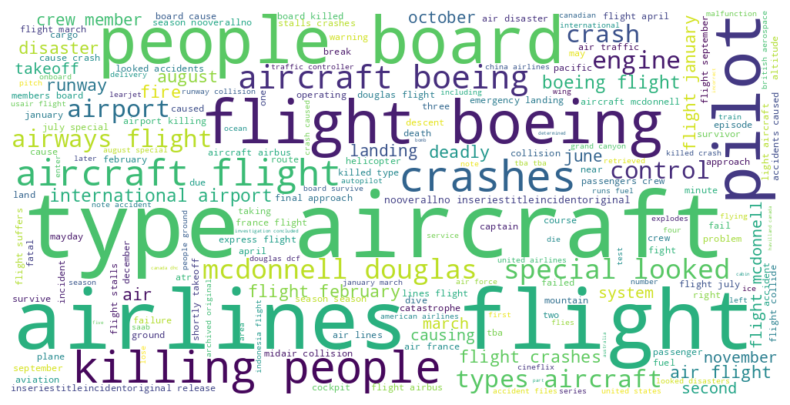

In [ ]:
# laod the saved HTML content from 'mayday_episodes.html'

# Step 1: Read the HTML file
saved_file ='mayday_episodes.html'
html_content = read_html_file(saved_file)
text = extract_text_from_html(html_content)
cleaned_text = clean_text(text)

print ("Word Cloud from entire html text")
print_wordcloud(cleaned_text)



In [ ]:

print ("Most frequent 5 words")
top_5_words = get_top_n_words(cleaned_text, n=5)
print(top_5_words)


print ("Most frequent 10 words")
top_10_words = get_top_n_words(cleaned_text, n=10)
print(top_10_words)

Most frequent 5 words
[('flight', 904), ('aircraft', 435), ('type', 227), ('airlines', 198), ('air', 180)]
Most frequent 10 words
[('flight', 904), ('aircraft', 435), ('type', 227), ('airlines', 198), ('air', 180), ('boeing', 178), ('board', 170), ('people', 150), ('crashes', 148), ('deadly', 137)]


## lets play with our existing dataframe


In [ ]:
df = df_episode #Both point to the same object (changes in df affect df_episode).



In [ ]:
df = df_episode.copy() # Creates a new, independent copy (safe from modifying the original).


In [ ]:
df.head()

,No.overall,No. inseries,Title,Incident,Original release date,Description
0,1,1,"""Unlocking Disaster""",United Airlines Flight 811,10 September 2003 (2003-09-10),"On 24 February 1989, part of the right-side fu..."
1,2,2,"""Racing the Storm""",American Airlines Flight 1420,3 September 2003 (2003-09-03),"On 1 June 1999, American Airlines Flight 1420 ..."
2,3,3,"""Fire on Board""",Swissair Flight 111,22 October 2003 (2003-10-22),"On 2 September 1998, a fire breaks out on Swis..."
3,4,4,"""Flying Blind""",Aeroperú Flight 603,17 September 2003 (2003-09-17),"On 2 October 1996, shortly after take off, the..."
4,5,5,"""Cutting Corners""",Alaska Airlines Flight 261,15 October 2003 (2003-10-15),"On 31 January 2000, Alaska Airlines Flight 261..."


In [ ]:
df.head(2)


,No.overall,No. inseries,Title,Incident,Original release date,Description
0,1,1,"""Unlocking Disaster""",United Airlines Flight 811,10 September 2003 (2003-09-10),"On 24 February 1989, part of the right-side fu..."
1,2,2,"""Racing the Storm""",American Airlines Flight 1420,3 September 2003 (2003-09-03),"On 1 June 1999, American Airlines Flight 1420 ..."


In [ ]:
df.tail(3)

,No.overall,No. inseries,Title,Incident,Original release date,Description
284,54,4,"""Landing Hazards""",Martinair Flight 495 American Airlines Flight ...,29 July 2024 (2024-07-29),This special looked at the threat bad weather ...
285,55,5,"""Training Ignored""",2020 Calabasas helicopter crash Corporate Airl...,5 August 2024 (2024-08-05),This special looked at accidents caused by pil...
286,56,6,"""Reckless Approaches""",Execuflight Flight 1526 Flagship Airlines Flig...,12 August 2024 (2024-08-12),This special looked at careless approaches. \n...


In [ ]:
# lets remove a column
df.drop('No.', axis=1, inplace=True)


KeyError: "['No.'] not found in axis"

In [ ]:
# SLICING
df.loc[0:2,'Title']

,Title
0,"""Unlocking Disaster"""
1,"""Racing the Storm"""
2,"""Fire on Board"""


In [ ]:
# SLICING
df.loc[2:5,'Description']

,Description
2,"On 2 September 1998, a fire breaks out on Swis..."
3,"On 2 October 1996, shortly after take off, the..."
4,"On 31 January 2000, Alaska Airlines Flight 261..."
5,"On 24 August 2001, Air Transat Flight 236 runs..."


In [ ]:
# SLICING
df.iloc[0:2,1]

,No. inseries
0,1
1,2


In [ ]:
# SLICING
df.iloc[0:2,:]

,No.overall,No. inseries,Title,Incident,Original release date,Description
0,1,1,"""Unlocking Disaster""",United Airlines Flight 811,10 September 2003 (2003-09-10),"On 24 February 1989, part of the right-side fu..."
1,2,2,"""Racing the Storm""",American Airlines Flight 1420,3 September 2003 (2003-09-03),"On 1 June 1999, American Airlines Flight 1420 ..."


In [ ]:
# SLICING
df.iloc[:,0:2]

,No.overall,No. inseries
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5
...,...,...
282,52,2
283,53,3
284,54,4
285,55,5


what can be done??
seeing -> fatalities_count, date, aircraft type, error type

what could be input here??
date, aircraft type, error type

output??
fatalities_count

what other could be done??
1.  designing model for above input and output,
2.  defining accident type,
3. aircraft model and age,
4. weather conditions (if applicable)
5. Accident severity prediction (eg: Low/ Medium/ High)
Features:
*   Structued: Fatalities count, accident type(mechanical/human error)
*   Text: Episodes summaries (TF- IDF (top frequency- inverse document frequency), word embedding)
*   Temporal: Air date (seasonality effects)


Validation??

Generalization TEst Dataset: Aviation Safety Network (ASN)
[link for aviation safety network](https://asn.flightsafety.org/database/)


outcome from above:




